# Grad-CAM demo — ConvNeXt-Tiny + Hybrid2 LSR

This notebook loads the trained `convnext_tiny_kaggle80k_320_lsr` checkpoint, predicts the five CheXpert labels for one frontal chest X-ray, and generates a Grad-CAM heatmap for explainability.

Recommended use for presentation:

**Input chest X-ray → predicted probabilities → Grad-CAM heatmap**

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

import matplotlib.pyplot as plt
from matplotlib import cm

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# Project configuration for your Windows setup
PROJECT_DIR = Path(r"C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project")
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
LOCAL_READY_DIR = PROJECT_DIR / "local_ready"
DELIVERABLES_DIR = PROJECT_DIR / "deliverables" / "gradcam_convnext_lsr"
DELIVERABLES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "convnext_tiny"
TAG = "convnext_tiny_kaggle80k_320_lsr"
STRATEGY = "kaggle80k_hybrid2_lsr_frontal"

CHECKPOINT_PATH = MODELS_DIR / f"{MODEL_NAME}_{TAG}_{STRATEGY}_best.pt"
TEST_CSV = LOCAL_READY_DIR / f"test_{STRATEGY}_local.csv"
THRESHOLDS_PATH = RESULTS_DIR / TAG / "best_thresholds_f1.json"

print("Checkpoint exists:", CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)
print("Test CSV exists:", TEST_CSV.exists(), TEST_CSV)
print("Thresholds exists:", THRESHOLDS_PATH.exists(), THRESHOLDS_PATH)
print("Output dir:", DELIVERABLES_DIR)

Checkpoint exists: True C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\models\convnext_tiny_convnext_tiny_kaggle80k_320_lsr_kaggle80k_hybrid2_lsr_frontal_best.pt
Test CSV exists: True C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\local_ready\test_kaggle80k_hybrid2_lsr_frontal_local.csv
Thresholds exists: True C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\results\convnext_tiny_kaggle80k_320_lsr\best_thresholds_f1.json
Output dir: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\gradcam_convnext_lsr


In [3]:
DEFAULT_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion",
]


def build_convnext_tiny(num_labels: int, dropout: float = 0.40):
    weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = models.convnext_tiny(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_labels))
    mean = weights.transforms().mean
    std = weights.transforms().std
    target_layer = model.features[-1]
    return model, mean, std, target_layer

In [4]:
# Load checkpoint
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

labels = checkpoint.get("target_labels", DEFAULT_LABELS)
config = checkpoint.get("config", {})
dropout = float(config.get("dropout", 0.40))
img_size = int(config.get("img_size", 320))

model, mean, std, target_layer = build_convnext_tiny(num_labels=len(labels), dropout=dropout)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Loaded:", CHECKPOINT_PATH.name)
print("Best epoch:", checkpoint.get("best_epoch"))
print("Best val AUC:", checkpoint.get("best_val_auc"))
print("Labels:", labels)
print("Image size:", img_size)
print("Device:", DEVICE)

Loaded: convnext_tiny_convnext_tiny_kaggle80k_320_lsr_kaggle80k_hybrid2_lsr_frontal_best.pt
Best epoch: 8
Best val AUC: 0.7985734197061826
Labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
Image size: 320
Device: cuda


In [5]:
# Load thresholds and test set
if THRESHOLDS_PATH.exists():
    with open(THRESHOLDS_PATH, "r", encoding="utf-8") as f:
        thresholds = json.load(f)
else:
    thresholds = {label: 0.5 for label in labels}

print("Thresholds:")
for label in labels:
    print(f"  {label}: {float(thresholds.get(label, 0.5)):.3f}")

df_test = pd.read_csv(TEST_CSV)
print("Test rows:", len(df_test))
df_test.head(3)

Thresholds:
  Atelectasis: 0.340
  Cardiomegaly: 0.450
  Consolidation: 0.350
  Edema: 0.400
  Pleural Effusion: 0.560
Test rows: 10000


,Path,local_image_path,patient_id,study_id,source_split,Sex,Age,Frontal/Lateral,AP/PA,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
0,CheXpert-v1.0-small/train/patient00009/study1/...,C:\Users\User\Documents\BIOMEDICINA\Noveno\Red...,patient00009,study1,kaggle_train,Male,76,Frontal,PA,1,1,0,0,0
1,CheXpert-v1.0-small/train/patient00016/study1/...,C:\Users\User\Documents\BIOMEDICINA\Noveno\Red...,patient00016,study1,kaggle_train,Female,54,Frontal,PA,0,0,1,0,0
2,CheXpert-v1.0-small/train/patient00022/study2/...,C:\Users\User\Documents\BIOMEDICINA\Noveno\Red...,patient00022,study2,kaggle_train,Female,55,Frontal,PA,0,0,0,0,1


In [ ]:
# Select image
# Option A: random test image
row = df_test.sample(1, random_state=random.randint(1, 999999)).iloc[0]

# Option B: uncomment to select manually by row index
# row = df_test.iloc[25]

# Option C: uncomment to use an external image path
# manual_path = r"C:\path\to\view1_frontal.jpg"
# row = None

if row is not None:
    image_path = Path(row["local_image_path"])
    true_labels = {label: int(row[label]) for label in labels}
else:
    image_path = Path(manual_path)
    true_labels = None

print("Image:", image_path)
print("Exists:", image_path.exists())
print("True labels:", true_labels)

Image: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\archive\train\patient51135\study2\view1_frontal.jpg
Exists: True
True labels: {'Atelectasis': 1, 'Cardiomegaly': 0, 'Consolidation': 0, 'Edema': 0, 'Pleural Effusion': 0}


: 

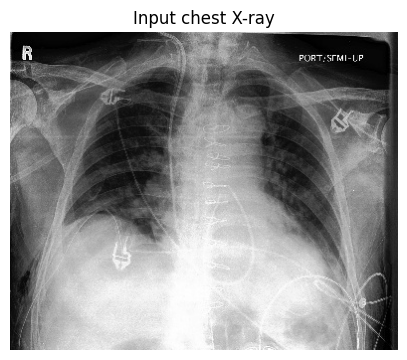

In [7]:
# Preprocess and show image
preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

img = Image.open(image_path).convert("RGB")
input_tensor = preprocess(img).unsqueeze(0).to(DEVICE)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Input chest X-ray")
plt.show()

In [8]:
# Predict probabilities
with torch.no_grad():
    logits = model(input_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

pred_table = pd.DataFrame({
    "label": labels,
    "probability": probs,
    "threshold": [float(thresholds.get(label, 0.5)) for label in labels],
})
pred_table["prediction"] = pred_table["probability"] >= pred_table["threshold"]
if true_labels is not None:
    pred_table["true_label"] = [true_labels[label] for label in labels]

pred_table = pred_table.sort_values("probability", ascending=False)
pred_table.to_csv(DELIVERABLES_DIR / "prediction_table.csv", index=False)
pred_table

,label,probability,threshold,prediction,true_label
3,Edema,0.734581,0.40,True,1
4,Pleural Effusion,0.678700,0.56,True,0
0,Atelectasis,0.610265,0.34,True,0
2,Consolidation,0.239901,0.35,False,0
1,Cardiomegaly,0.155419,0.45,False,0


In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        acts = self.activations
        grads = self.gradients
        if acts is None or grads is None:
            raise RuntimeError("Hooks did not capture activations/gradients.")

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam_tensor = (weights * acts).sum(dim=1, keepdim=True)
        cam_tensor = F.relu(cam_tensor)
        cam_tensor = F.interpolate(cam_tensor, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam_tensor[0, 0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def overlay_cam_on_image(image, cam, alpha=0.42):
    image_resized = image.resize((cam.shape[1], cam.shape[0]))
    base = np.asarray(image_resized).astype(np.float32) / 255.0
    heatmap = cm.get_cmap("jet")(cam)[..., :3]
    overlay = (1.0 - alpha) * base + alpha * heatmap
    return np.clip(overlay, 0.0, 1.0)

Explaining: Edema probability= 0.7345811724662781


C:\Users\User\AppData\Local\Temp\ipykernel_33532\1514875173.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap("jet")(cam)[..., :3]


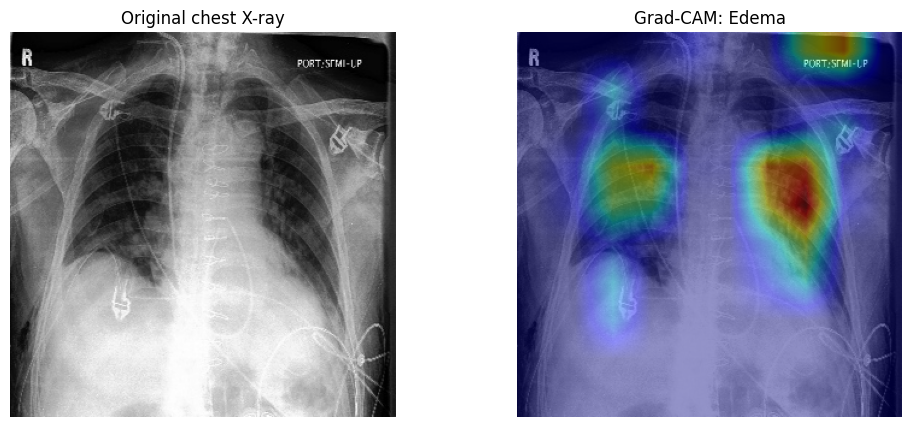

In [10]:
# Generate Grad-CAM
# Default: explain highest-probability class
class_name = pred_table.iloc[0]["label"]
class_idx = labels.index(class_name)

# Or explain a specific pathology:
# class_name = "Pleural Effusion"
# class_idx = labels.index(class_name)

print("Explaining:", class_name, "probability=", float(probs[class_idx]))

gradcam = GradCAM(model, target_layer)
cam = gradcam(input_tensor, class_idx)
gradcam.close()

overlay = overlay_cam_on_image(img, cam)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img.resize((img_size, img_size)), cmap="gray")
plt.axis("off")
plt.title("Original chest X-ray")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.axis("off")
plt.title(f"Grad-CAM: {class_name}")
plt.show()

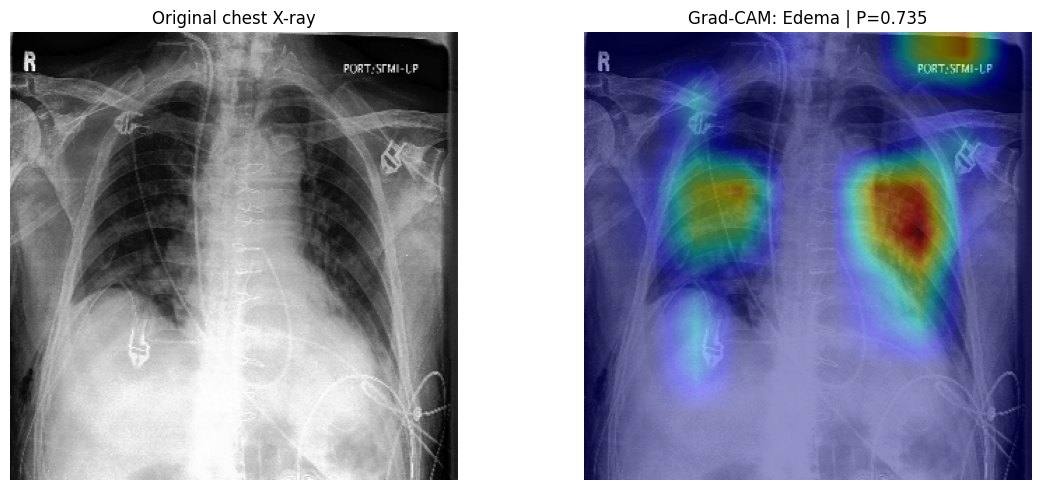

Saved: C:\Users\User\Documents\BIOMEDICINA\Noveno\Redes Neuronales\chexpert_kaggle_final_project\deliverables\gradcam_convnext_lsr\gradcam_Edema.png


In [11]:
# Save figure for presentation
safe_class_name = class_name.replace(" ", "_").replace("/", "_")
fig_path = DELIVERABLES_DIR / f"gradcam_{safe_class_name}.png"

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img.resize((img_size, img_size)), cmap="gray")
plt.axis("off")
plt.title("Original chest X-ray")

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.axis("off")
plt.title(f"Grad-CAM: {class_name} | P={float(probs[class_idx]):.3f}")

plt.tight_layout()
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

## How to explain this in the presentation

Grad-CAM is used as a visual interpretability technique. It highlights the image regions that contributed most strongly to the model prediction for a selected pathology. In this project, Grad-CAM is used only as a support tool for model transparency and not as a replacement for radiologist interpretation.